# 03 - Modelagem

## Objetivo
Treinar e comparar 3 modelos de classificacao para diagnostico de cancer de mama:
- Regressao Logistica
- Arvore de Decisao
- KNN

Criterio de escolha do modelo principal:
1. Maior recall para classe maligna (1)
2. Maior F1-score
3. Maior accuracy (desempate)

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 1. Carregar dados processados

In [2]:
base_path = '../data/processed'

X_train_raw = pd.read_csv(f'{base_path}/X_train_raw.csv')
X_test_raw = pd.read_csv(f'{base_path}/X_test_raw.csv')
X_train_scaled = pd.read_csv(f'{base_path}/X_train_scaled.csv')
X_test_scaled = pd.read_csv(f'{base_path}/X_test_scaled.csv')
y_train = pd.read_csv(f'{base_path}/y_train.csv').squeeze()
y_test = pd.read_csv(f'{base_path}/y_test.csv').squeeze()

print('Dados carregados com sucesso.')
print(f'X_train_raw: {X_train_raw.shape} | X_test_raw: {X_test_raw.shape}')
print(f'X_train_scaled: {X_train_scaled.shape} | X_test_scaled: {X_test_scaled.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')

Dados carregados com sucesso.
X_train_raw: (455, 30) | X_test_raw: (114, 30)
X_train_scaled: (455, 30) | X_test_scaled: (114, 30)
y_train: (455,) | y_test: (114,)


## 2. Definir modelos e dados de entrada

Observacao:
- Regressao Logistica e KNN usam dados padronizados
- Arvore de Decisao usa dados sem padronizacao

In [3]:
model_configs = {
    'Regressao Logistica': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'X_train': X_train_scaled,
        'X_test': X_test_scaled
    },
    'Arvore de Decisao': {
        'model': DecisionTreeClassifier(random_state=42, max_depth=5),
        'X_train': X_train_raw,
        'X_test': X_test_raw
    },
    'KNN': {
        'model': KNeighborsClassifier(n_neighbors=7),
        'X_train': X_train_scaled,
        'X_test': X_test_scaled
    }
}

print('Modelos configurados.')

Modelos configurados.


## 3. Treino e avaliacao

In [4]:
resultados = []
predicoes = {}

for nome, cfg in model_configs.items():
    modelo = cfg['model']
    Xtr = cfg['X_train']
    Xte = cfg['X_test']

    modelo.fit(Xtr, y_train)
    y_pred = modelo.predict(Xte)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    resultados.append({
        'modelo': nome,
        'accuracy': round(acc, 4),
        'recall_maligno': round(rec, 4),
        'f1_maligno': round(f1, 4)
    })

    predicoes[nome] = {
        'y_pred': y_pred,
        'modelo': modelo
    }

df_resultados = pd.DataFrame(resultados).sort_values(
    by=['recall_maligno', 'f1_maligno', 'accuracy'],
    ascending=False
).reset_index(drop=True)

df_resultados

,modelo,accuracy,recall_maligno,f1_maligno
0,Regressao Logistica,0.9649,0.9286,0.9512
1,KNN,0.9561,0.9048,0.9383
2,Arvore de Decisao,0.9211,0.8333,0.8861


## 4. Escolha automatica do melhor modelo

In [5]:
melhor_modelo_nome = df_resultados.iloc[0]['modelo']
melhor_modelo = predicoes[melhor_modelo_nome]['modelo']
melhor_pred = predicoes[melhor_modelo_nome]['y_pred']

print(f'Melhor modelo selecionado: {melhor_modelo_nome}')
print(df_resultados.iloc[0])

Melhor modelo selecionado: Regressao Logistica
modelo            Regressao Logistica
accuracy                       0.9649
recall_maligno                 0.9286
f1_maligno                     0.9512
Name: 0, dtype: object


## 5. Relatorio de classificacao por modelo

In [6]:
for nome, dados in predicoes.items():
    print('=' * 70)
    print(f'MODELO: {nome}')
    print(classification_report(y_test, dados['y_pred'], target_names=['Benigno (0)', 'Maligno (1)']))

MODELO: Regressao Logistica
              precision    recall  f1-score   support

 Benigno (0)       0.96      0.99      0.97        72
 Maligno (1)       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

MODELO: Arvore de Decisao
              precision    recall  f1-score   support

 Benigno (0)       0.91      0.97      0.94        72
 Maligno (1)       0.95      0.83      0.89        42

    accuracy                           0.92       114
   macro avg       0.93      0.90      0.91       114
weighted avg       0.92      0.92      0.92       114

MODELO: KNN
              precision    recall  f1-score   support

 Benigno (0)       0.95      0.99      0.97        72
 Maligno (1)       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted

## 6. Matriz de confusao (todos os modelos)

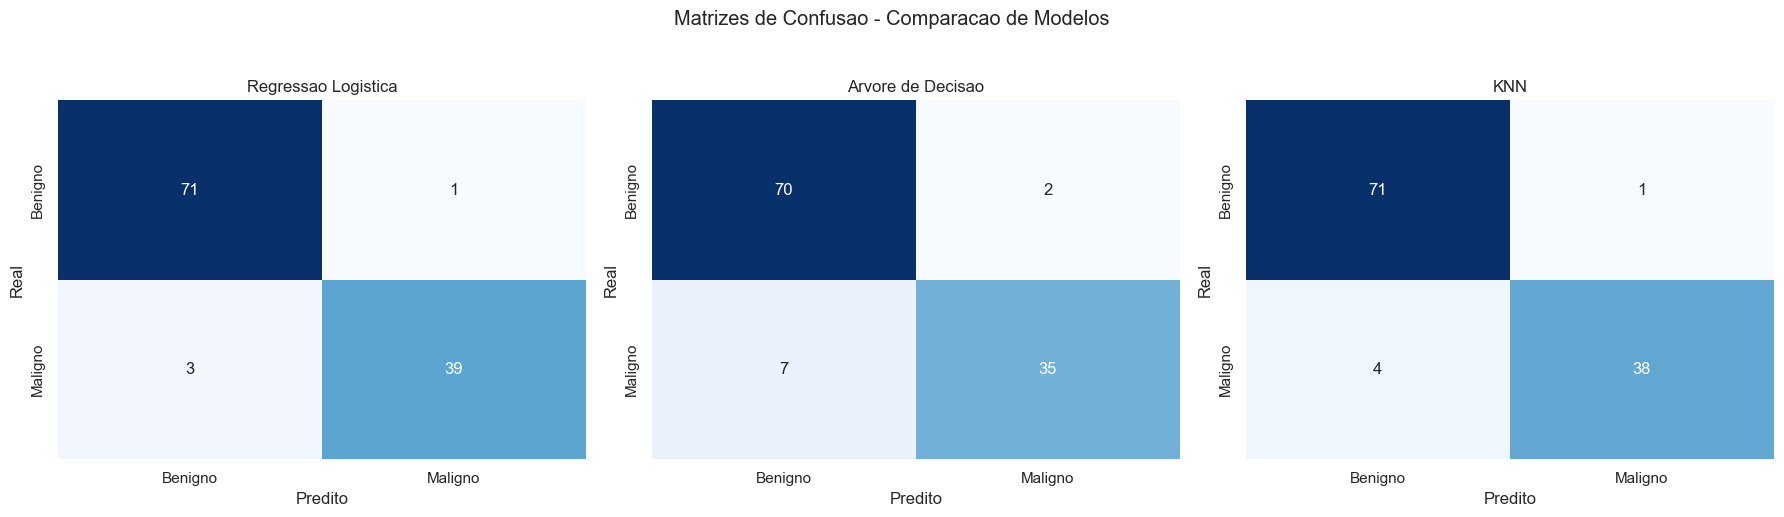

In [7]:
os.makedirs('../outputs/figures', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, dados) in zip(axes, predicoes.items()):
    cm = confusion_matrix(y_test, dados['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(nome)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
    ax.set_xticklabels(['Benigno', 'Maligno'])
    ax.set_yticklabels(['Benigno', 'Maligno'])

plt.suptitle('Matrizes de Confusao - Comparacao de Modelos', y=1.03)
plt.tight_layout()
plt.savefig('../outputs/figures/matrizes_confusao_modelos.png', dpi=150)
plt.show()

## 7. Salvar ranking de modelos

Este arquivo sera usado no relatorio tecnico.

In [8]:
os.makedirs('../outputs/models', exist_ok=True)
df_resultados.to_csv('../outputs/models/ranking_modelos.csv', index=False)
print('Ranking salvo em outputs/models/ranking_modelos.csv')

Ranking salvo em outputs/models/ranking_modelos.csv


## Conclusao

Etapa 4 concluida com comparacao dos 3 modelos e escolha objetiva do modelo principal.

Proximo passo: Etapa 5 (explicabilidade) com:
- Feature importance
- SHAP
- Analise critica dos erros